In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Temporal-Difference Learning and Exploration

Q-learning does not require a transition model or expert demonstrations. It replaces the expectation in the Bellman optimality operator with a sampled transition and updates an action-value estimate using the resulting temporal-difference error [@Watkins.1989; @Watkins.Dayan.1992]. This substitution introduces sampling noise and makes convergence depend on which state--action pairs the behavior policy visits. We first derive and evaluate the tabular update, then study exploration through multi-armed bandits and regret.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import gymnasium as gym
import numpy as np

## The Sampled Backup

### From the Bellman Operator to the TD Update

Value iteration, written for the action-value function, sweeps

$$Q_{k+1}(s, a) = r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a) \max_{a' \in \mathcal{A}} Q_k (s', a'); \ \textrm{for all } s \in \mathcal{S} \textrm{ and } a \in \mathcal{A},$$

whose fixed point is $Q^*$; call the right-hand side $(TQ)(s, a)$, the optimality operator of that section on action-value tables. We use $Q$ rather than $V$ because extracting the optimal policy from $Q^*$ requires only an argmax over a table row and no transition model. The kernel enters the sweep through one expectation, $E_{s' \sim P(\cdot \mid s, a)} [\max_{a'} Q_k(s', a')]$, and an expectation can be estimated from samples. Panel (d) of the figure shows this substitution: Q-learning uses one sampled successor where the exact backup sums over every successor, while retaining the maximum over next actions.

Let the agent act with some data-collection policy $\pi_e(a \mid s)$, its *behavior policy*, and record $n$ trajectories of $T$ timesteps each, $\{ (s_t^i, a_t^i)_{t=0,\ldots,T-1}\}_{i=1,\ldots, n}$. The Bellman equations constrain the action values of all state--action pairs. A sampled objective can impose corresponding residual terms only for pairs present in the data:

$$\hat{Q} = \mathrm{argmin}_Q \underbrace{\frac{1}{nT} \sum_{i=1}^n \sum_{t=0}^{T-1} (Q(s_t^i, a_t^i) - r(s_t^i, a_t^i) - \gamma \max_{a'} Q(s_{t+1}^i, a'))^2}_{\stackrel{\textrm{def}}{=} \ell(Q)}.$$

The objective does not evaluate the kernel explicitly. Instead, when the behavior policy $\pi_e$ takes action $a_t^i$ at state $s_t^i$, the next state $s_{t+1}^i$ is sampled from the transition distribution. The collected data therefore provide sampled access to the transition dynamics. For every constraint to be represented, $\pi_e$ must keep visiting every state-action pair.

An optimal deterministic policy would *not* qualify: it never takes the actions it considers suboptimal, so $\ell(Q)$ would contain no term for those state-action pairs and their values would be left unconstrained. The third part of this section takes that requirement seriously.

Instead of solving the joint problem directly, Q-learning updates individual table entries. For each observed transition $(s, a, r, s')$, it moves the corresponding entry toward the *bootstrapped target* $r + \gamma \max_{a'} Q(s', a')$, treating the target as a constant even though it contains $Q$:

$$Q(s, a) \leftarrow (1 - \alpha)\, Q(s, a) + \alpha \big( r + \gamma \max_{a'} Q(s', a') \big),$$

where $\alpha$ is the step size. Because the target itself depends on $Q$ and we deliberately hold it fixed, this is called a semi-gradient step: Q-learning is therefore not gradient descent on $\ell(Q)$ in the strict sense; it is a semi-gradient stochastic-approximation update. Rearranged, the update is a correction proportional to a single scalar,

$$\delta = r + \gamma \max_{a'} Q(s', a') - Q(s, a), \qquad Q(s, a) \leftarrow Q(s, a) + \alpha\, \delta.$$

The scalar $\delta$ is the *temporal-difference error* [@Sutton.1988]: the observed reward plus the estimated best continuation, minus the current estimate. It also appears in the actor updates of that section and in deep Q-learning (that section).

*Monte Carlo* prediction waits until an episode ends and uses the realized return as a target for $Q^{\pi_e}(s_t,a_t)$, the value of the behavior policy. The target is unbiased but contains randomness from all subsequent transitions. *Temporal-difference* prediction bootstraps after one step; its target is biased while the value estimate is inaccurate but usually has lower variance [@Sutton.1988; @Sutton.Barto.2018]. Q-learning uses a maximum in this target to estimate $Q^*$. The multi-step methods of that section interpolate between Monte Carlo and one-step targets.

### Convergence and the Double-Sampling Problem

Suppose $\pi_e$ visits every state--action pair and collects unlimited data. Minimizing $\ell(Q)$ then recovers the value-iteration solution when transitions are deterministic, but not in general. In the population objective, conditioning on $(s,a)$ decomposes each squared term into a squared mean and a variance:

$$L(Q) = E_{(s, a) \sim \mu} \Big[ \big( Q(s, a) - (TQ)(s, a) \big)^2 \Big] + \gamma^2\, E_{(s, a) \sim \mu} \Big[ \mathrm{Var}_{s' \sim P(\cdot \mid s, a)} \big( \max_{a'} Q(s', a') \big) \Big],$$

Here $\mu$ is the visitation distribution of $\pi_e$. The first term is the squared Bellman residual and is zero at $Q^*$. The second term depends on $Q$ whenever transitions are stochastic, so the minimizer of $L$ need not be $Q^*$. Exercise 4 gives a three-state counterexample. This is the *double-sampling problem*: an unbiased gradient of the squared Bellman residual requires two independent successors for the same $(s,a)$, which an ordinary environment interaction does not provide. For deterministic transitions the variance term vanishes.

Convergence instead follows from the expected update. Averaging the equation over $s'$ gives $E[\delta\mid s,a]=(TQ)(s,a)-Q(s,a)$, which is zero at the unique fixed point $Q^*$. Q-learning is therefore a stochastic approximation to Bellman fixed-point iteration. With the step-size conditions below and infinite visitation of every state-action pair, it converges to $Q^*$ with probability one [@Watkins.Dayan.1992; @Jaakkola.Jordan.Singh.1994]. Sampling variance affects the rate, while the behavior policy determines whether the coverage condition holds.

### Step Sizes and the Robbins-Monro Conditions

For each state-action pair, the Robbins--Monro conditions are $\sum_k\alpha_k=\infty$ and $\sum_k\alpha_k^2<\infty$ [@Robbins.Monro.1951]. A constant step size violates the second condition. With stochastic transitions, its estimates continue to fluctuate around $Q^*$. In a deterministic environment, the target has no transition noise and an update has the form $Q(s,a)\leftarrow(1-\alpha)Q(s,a)+\alpha(TQ)(s,a)$. Updating all entries gives a contraction with modulus $(1-\alpha)+\alpha\gamma$. The sampled asynchronous method additionally requires repeated visitation of every entry.

Panel (c) of the figure measures this coverage for deterministic FrozenLake, where a constant step size of $0.9$ learns quickly within the finite budget.

The conditions are necessary for the guarantee, not sufficient for a budget. The textbook sample-average rule $\alpha = 1/(1 + n(s, a))$, with $n(s, a)$ counting visits to the entry, passes Robbins-Monro but weights early targets computed from an inaccurate zero table as heavily as later, better-informed targets. At the tested finite budget, this slows learning substantially. Our default $\alpha = 1/(1 + 0.1\, n(s, a))$ also passes but stays ten times larger at the same visit count. We compare all three schedules on the same seeds and report their finite-budget value errors and returns.

### Terminal Masking

The update requires terminal masking in an episodic environment. When $s'$ is terminal, its continuation value is zero, so the target contains only the immediate reward,

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big( r + \gamma\, \big(1 - \mathbf{1}(s' \textrm{ terminal})\big) \max_{a' \in \mathcal{A}} Q(s', a') - Q(s, a) \Big).$$

The mask uses `terminated`, not `truncated`: that section distinguishes a terminal state from an observation stopped by a time limit. Treating truncation as termination would impose an incorrect zero continuation value on a nonterminal state. In code the whole repair is one factor, `gamma * (1 - terminated) * Q[s_next].max()`.

## Q-Learning on the Lake

### The Implementation

We return to the slippery lake of that section with the same discount. The learner accesses the environment only through `reset` and `step`; `mdp`, `V_star`, and `pi_star` are retained solely to compare the learned table with the exact solution.

In [2]:
gamma, num_episodes = 0.95, 4000
env = gym.make('FrozenLake-v1', is_slippery=True)
mdp = d2l.TabularMDP.from_gym(env, gamma)
V_star = d2l.value_iteration(mdp, num_iters=1000)[-1]
pi_star = mdp.backup(V_star).argmax(axis=1)

Two helpers, both plain numpy and both saved: the deep Q-network of that section and the PPO of that section will call them unchanged. The first turns a start value, an end value and a horizon into a schedule:

In [3]:
def linear_schedule(start, end, num_steps):
    """step -> value, interpolated from start to end, then held at end."""
    return lambda step: end + (start - end) * max(0.0, 1.0 - step / num_steps)

The second is the behavior policy. With probability $\epsilon$ it takes a uniformly random action; otherwise it exploits the current table:

$$\pi_e(a \mid s) = \begin{cases} 1 - \epsilon + \epsilon/|\mathcal{A}| & a = \mathrm{argmax}_{a'} \hat{Q}(s, a') \\ \epsilon/|\mathcal{A}| & \textrm{otherwise}, \end{cases}$$

the *$\epsilon$-greedy* policy, with ties in the argmax broken uniformly at random. Random tie-breaking is necessary for exploration from a zero-initialized table, where every state begins as a four-way tie. In contrast, `np.argmax` always returns the first index:

In [4]:
def epsilon_greedy(q, epsilon, rng):
    """Explore with probability epsilon, else act greedily on the values q."""
    if rng.random() < epsilon:
        return int(rng.integers(len(q)))
    # Random tie-breaking is load-bearing: np.argmax would always return
    # action 0 on a zero-initialized table, and an agent that only ever
    # proposes *left* on this lake never finds the goal.
    return int(rng.choice(np.flatnonzero(q == q.max())))

The implementation repeatedly selects an action, observes one transition, and changes one table entry by $\alpha\delta$. It mutates both the value table and the visit counts; the counts determine the step-size schedule and also record state--action coverage. The exploration rate decreases from $1$ to $0.05$ during the first half of training and remains at that floor thereafter:

In [5]:
def q_learning(seed, Q, visits, env, num_episodes,
               alpha=lambda n: 1 / (1 + 0.1 * n)):
    """Tabular Q-learning; updates Q in place, yields each episode's return."""
    rng = np.random.default_rng(seed)
    epsilon = linear_schedule(1.0, 0.05, num_episodes // 2)
    env.reset(seed=seed)
    for episode in range(num_episodes):
        s, done, ret = env.reset()[0], False, 0.0
        while not done:
            a = epsilon_greedy(Q[s], epsilon(episode), rng)
            s_next, r, terminated, truncated, _ = env.step(a)
            visits[s, a] += 1
            delta = r + gamma * (1 - terminated) * Q[s_next].max() - Q[s, a]
            Q[s, a] += alpha(visits[s, a]) * delta
            s, done, ret = s_next, terminated or truncated, ret + r
        yield ret

Every cell here is numpy and shared between the frameworks: tabular reinforcement learning is index arithmetic, and the frameworks enter when the table becomes a network in that section. Five seeds, one plain loop:

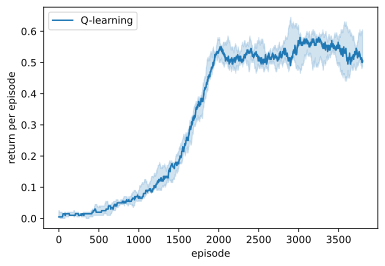

In [6]:
Q = np.zeros((5, mdp.num_states, mdp.num_actions))
visits = np.zeros_like(Q)
returns = np.array([list(q_learning(k, Q[k], visits[k], env, num_episodes))
                    for k in range(5)])
d2l.plot_curves({'Q-learning': returns}, xlabel='episode',
                ylabel='return per episode', smooth=200)

The curve is a trailing 200-episode average, with the band spanning the seeds. It remains near zero while successful episodes are rare, increases as successful transitions update preceding state--action values, and flattens after the exploration schedule reaches its floor.

### The Learned Table against the Exact Solution

The curve plateaus near $0.55$, below the optimal success probability of $73.6$ percent measured in that section. This comparison includes failures caused by the behavior policy's continuing exploration and therefore does not directly assess the learned table. Because the exact solution is available for this example, we can compare the learned values with $V^*$:

In [7]:
print(f'max_s |V_Qhat(s) - V*(s)| per seed: '
      f'{np.round(np.abs(Q.max(axis=-1) - V_star).max(axis=-1), 3)}')
env.reset(seed=0)
opt = d2l.evaluate(env, lambda s, rng: int(pi_star[s]), num_episodes=2000)
rates = np.array([d2l.evaluate(env, lambda s, rng: int(Q[k, s].argmax()),
                               num_episodes=2000) for k in range(5)])
taxed = d2l.evaluate(env, lambda s, rng: int(pi_star[s])
                     if rng.random() > 0.05 else int(rng.integers(4)),
                     num_episodes=2000, rng=np.random.default_rng(1))
print(f'success rate: learned greedy {rates.min():.1%} to {rates.max():.1%} '
      f'over 5 seeds; pi* {opt:.1%}')
print(f'pi* forced to explore at epsilon = 0.05: {taxed:.1%}')
print(f'median environment steps: {int(np.median(visits.sum(axis=(1, 2))))}')

max_s |V_Qhat(s) - V*(s)| per seed: [0.019 0.012 0.021 0.008 0.006]


success rate: learned greedy 71.2% to 74.1% over 5 seeds; pi* 73.6%
pi* forced to explore at epsilon = 0.05: 54.1%
median environment steps: 95569


Across seeds, the learned value functions are within $0.006$ to $0.021$ of $V^*$ in the sup norm. Their greedy policies succeed in $71$ to $74$ percent of evaluation episodes, compared with the optimal value of $73.6$ percent; differences within this range are sampling error. When the optimal policy is forced to select a random action with probability $0.05$, its success rate falls to $54$ percent. The training curve therefore reflects both the learned policy and the continuing exploration of the behavior policy.

The median run used $95{,}569$ environment steps. By comparison, that section certified $V^*$ after $164$ sweeps of $64$ exact model backups, or about $10{,}500$ backups. These quantities are not directly interchangeable: a Bellman backup requires the full transition kernel, whereas an environment step provides only one sampled transition. Exercise 5 compares the two methods while keeping these different information requirements explicit.

The following panels compare the learned and exact solutions:

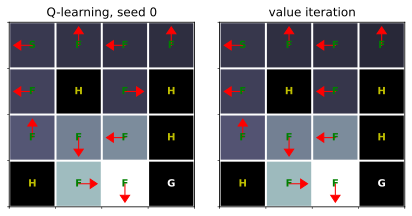

In [8]:
d2l.show_grid(env.unwrapped.desc, np.stack([Q[0].max(-1), V_star]),
              np.stack([Q[0].argmax(-1), pi_star]),
              titles=['Q-learning, seed 0', 'value iteration'])

The learned arrows reproduce the slip-aware strategy of that section
except at state $6$: Q-learning selects *right*, whereas $\pi^*$ selects
*left*. State $6$ lies between holes $5$ and $7$, and the two actions have
equal values under $Q^*$, so this disagreement is a different resolution of an
exact tie. The value estimates are most accurate in frequently visited states
and coarser in the rarely visited top-right corner.

Now consider the deterministic special case. Disabling slip produces
deterministic transitions and noiseless targets, for which the
damped-contraction argument permits the constant $\alpha = 0.9$. In this
experiment, one sixteenth of the episode budget suffices:

In [9]:
calm = gym.make('FrozenLake-v1', is_slippery=False)
table = np.zeros((mdp.num_states, mdp.num_actions))
for _ in q_learning(0, table, np.zeros_like(table), calm, 256,
                    alpha=lambda n: 0.9):
    pass
print(f'calm ice, 256 episodes, alpha = 0.9: greedy policy succeeds '
      f'{d2l.evaluate(calm, lambda s, rng: int(table[s].argmax()), 100):.0%}')

calm ice, 256 episodes, alpha = 0.9: greedy policy succeeds 100%


In the deterministic environment, the same method finds a perfect policy with about one sixteenth as many episodes and can use a much larger step size. This contrast shows how transition noise changes the sample and step-size requirements. To compare the three schedules, we track $Q(s_0,\textrm{left})$ across the same five seeds; its exact value is available from dynamic programming.

Q*(s0, <) = 0.180


alpha = 0.9 (constant): final estimates [0.056 0.221 0.206 0.265 0.236]


alpha =  1/(1 + 0.1 n): final estimates [0.19  0.186 0.195 0.184 0.18 ]


alpha =      1/(1 + n): final estimates [0.003 0.024 0.008 0.009 0.002]


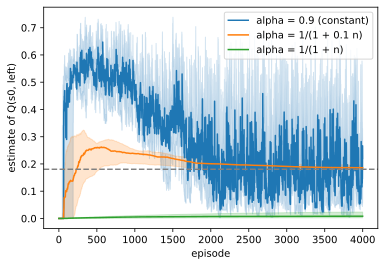

In [10]:
Q_star = mdp.backup(V_star)
a0 = int(pi_star[0])
print(f'Q*(s0, {"<v>^"[a0]}) = {Q_star[0, a0]:.3f}')
trace = {}
for name, alpha in [('0.9 (constant)', lambda n: 0.9),
                    ('1/(1 + 0.1 n)', lambda n: 1 / (1 + 0.1 * n)),
                    ('1/(1 + n)', lambda n: 1 / (1 + n))]:
    runs = []
    for seed in range(5):
        Qa = np.zeros_like(Q[0])
        runs.append([Qa[0, a0] for _ in q_learning(
            seed, Qa, np.zeros_like(Qa), env, num_episodes, alpha)])
    trace[f'alpha = {name}'] = np.array(runs)
    print(f'alpha = {name:>14}: final estimates {np.round(runs, 3)[:, -1]}')
d2l.plot_curves(trace, xlabel='episode', ylabel='estimate of Q(s0, left)',
                reference=Q_star[0, a0])

The constant step size does not converge to a fixed value: after four thousand episodes, the five estimates range from $0.06$ to $0.27$, compared with the exact value $0.180$. The default decreasing schedule places all five estimates between $0.180$ and $0.195$. The sample-average schedule $1/(1+n)$ also satisfies the Robbins--Monro conditions, but all five estimates remain below $0.025$ at this budget because early, inaccurate targets retain substantial weight. The asymptotic conditions therefore do not determine which schedule performs best at a finite horizon.

### Feedback between Estimation and Data Collection

The behavior policy depends on the current value estimates, so estimation errors influence which data are collected next. If $\hat{Q}(s,a)$ is too large, an $\epsilon$-greedy policy selects $a$ more often and produces additional transitions whose expected TD errors reduce the overestimate. An underestimate is corrected less directly, because the action may be selected only through random exploration. This creates an asymmetry between overestimation and underestimation.

At a fixed point, the expected correction must vanish for every state--action pair visited by the behavior policy. By the equation, this is precisely the Bellman optimality condition on the visited set. Interaction can therefore direct data collection toward errors in the current estimate. Offline reinforcement learning, introduced in that section, removes this feedback because it learns from a fixed dataset.

The preceding argument assumes continued exploration. To isolate the resulting tradeoff, we next study a multi-armed bandit, which removes state transitions and delayed rewards.

## Exploration and Regret

### The Multi-Armed Bandit

To isolate exploration, use the one-state MDP from that section.
Without transitions or delayed rewards, the resulting *multi-armed
bandit* requires the agent to balance estimating action values against
selecting actions with high expected reward. We use ten Bernoulli arms,
one of which has the largest success probability:

In [11]:
arms = np.array([0.50, 0.42, 0.90, 0.25, 0.55, 0.38, 0.60, 0.32, 0.50, 0.45])

def bandit_run(rule, num_pulls, seed):
    """One state, one step: pull an arm, log the shortfall, update tallies."""
    rng = np.random.default_rng(seed)
    wins, count = np.zeros(len(arms)), np.zeros(len(arms))
    gap = np.empty(num_pulls)
    for t in range(num_pulls):
        a = rule(wins, count, t, rng)
        count[a] += 1
        wins[a] += float(rng.random() < arms[a])
        gap[t] = arms.max() - arms[a]
    return np.cumsum(gap)

A bandit policy is any rule from the running tallies to an arm, so
`epsilon_greedy` applies unchanged to the empirical means. In a
*contextual bandit*, a fresh context arrives each round independently of
previous actions, one action is scored, and the episode ends. The model
may generalize across contexts, but there are no controlled dynamics or
delayed rewards. that section uses this distinction when
classifying single-turn preference optimization.

### Regret and the Epsilon-Greedy Family

A bandit permits evaluation by cumulative regret rather than success rate. Each pull contributes the gap between the best mean $\mu^* = \max_a \mu_a$ and the selected arm's mean,

$$\textrm{regret after } t \textrm{ pulls} = \sum_{u=1}^{t} \big( \mu^* - \mu_{a_u} \big),$$

which is what `bandit_run` accumulates. Its expectation is $\sum_a (\mu^* - \mu_a)\, E[n(a)]$: the gap of each arm multiplied by its expected number of pulls. *Sublinear* regret means that average regret per pull converges to zero. We compare three members of the $\epsilon$-greedy family over twenty independent runs:

In [12]:
def eps_rule(schedule):
    """Epsilon-greedy on the empirical means, with epsilon = schedule(t)."""
    return lambda wins, count, t, rng: epsilon_greedy(
        wins / np.maximum(count, 1), schedule(t), rng)

rules = {'greedy': eps_rule(lambda t: 0.0),
         'epsilon = 0.1': eps_rule(lambda t: 0.1),
         'annealed': eps_rule(lambda t: max(0.02, 1 / np.sqrt(t + 1)))}
regret = {name: np.array([bandit_run(rule, 2000, [2026, i, s])
                          for s in range(20)])
          for i, (name, rule) in enumerate(rules.items())}
for name, r in regret.items():
    print(f'{name:>13}: mean regret after 2000 pulls {r[:, -1].mean():6.1f}')

       greedy: mean regret after 2000 pulls  824.0
epsilon = 0.1: mean regret after 2000 pulls  116.5
     annealed: mean regret after 2000 pulls   68.5


The greedy rule is sensitive to its first observations. It incurs little subsequent regret if it identifies the best arm early, but it can remain committed to a suboptimal arm; its mean regret is $824$. With fixed $\epsilon = 0.1$, the best arm is usually identified quickly, but uniform exploration continues throughout the run. For these arms this produces approximately $0.04$ regret per pull and a total of $117$. Annealing $\epsilon$ reduces exploration as the estimates improve and lowers the total regret to $69$.

![Exploration, measured three ways. (a) One row of action values, $\hat Q(s, \cdot) = (0.20, 0.90, 0.55, 0.10)$, converted into greedy, $\epsilon$-greedy with $\epsilon = 0.3$, and softmax policies with temperature $0.3$. (b) Mean cumulative regret over 20 runs on the ten-armed Bernoulli bandit, shown on logarithmic axes. After $2000$ pulls, the regrets are $824$ for greedy, $117$ for fixed $\epsilon = 0.1$, $69$ for annealed $\epsilon$, $37$ for UCB with $\kappa = 0.5$, and $32$ for Thompson sampling. These finite runs do not measure asymptotic rates. The inset shows the UCB radius $\kappa \sqrt{\log t/n}$ at $t = 2000$. (c) Coverage of the 44 nonterminal state-action pairs (solid) and success rate (dashed) under three schedules for tabular Q-learning on deterministic FrozenLake. With random tie-breaking, the greedy policy covers 92 percent of the pairs; $\epsilon = 1$ covers all pairs but does not learn a successful policy.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-exploration.svg)

### Optimism: UCB and Thompson Sampling

Panel (a) of the figure represents the preceding policies as distributions over a row of action values. It also includes the softmax policy introduced in that section, whose temperature controls how concentrated the distribution is. The two remaining methods use uncertainty to direct exploration. Optimistic initialization starts each estimate above the attainable rewards, so an arm continues to be selected until observations lower its estimate [@Sutton.Barto.2018]. The *upper confidence bound* (UCB) rule instead adds an uncertainty bonus and selects the largest upper confidence estimate:

$$a_t = \underset{a}{\mathrm{argmax}} \Big[ \hat{\mu}(a) + \kappa \sqrt{\log t \,/\, n(a)} \Big],$$

The bonus decreases with the number of observations $n(a)$ and increases slowly with $t$ while an arm is not selected [@Auer.CesaBianchi.Fischer.2002]. Thus UCB adapts exploration separately for each arm. With the standard coefficient $\kappa=\sqrt{2}$, its regret is logarithmic in $t$, whereas fixed-$\epsilon$ exploration has linear regret. Smaller coefficients can work better on a particular finite problem but no longer satisfy that guarantee. Each arm is played once to initialize its index; subsequent choices are deterministic maximizers of the UCB score. Thompson sampling [@Thompson.1933] takes a Bayesian approach. For Bernoulli rewards it maintains a Beta posterior for each arm, samples one mean from each posterior, and selects the arm with the largest sample. As observations accumulate, both methods concentrate their choices on well-supported arms:

          UCB: mean regret after 2000 pulls   36.5


     Thompson: mean regret after 2000 pulls   31.5


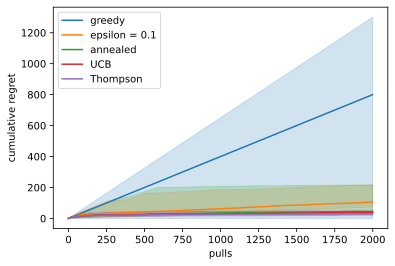

In [13]:
kappa = 0.5

def ucb(wins, count, t, rng):
    if (count == 0).any():          # play each arm once before pricing any
        return int(np.argmax(count == 0))
    return int(np.argmax(wins / count + kappa * np.sqrt(np.log(t) / count)))

def thompson(wins, count, t, rng):
    return int(rng.beta(1 + wins, 1 + count - wins).argmax())

for i, (name, rule) in enumerate([('UCB', ucb), ('Thompson', thompson)], 3):
    regret[name] = np.array([bandit_run(rule, 2000, [2026, i, s])
                             for s in range(20)])
    print(f'{name:>13}: mean regret after 2000 pulls '
          f'{regret[name][:, -1].mean():6.1f}')
d2l.plot_curves(regret, xlabel='pulls', ylabel='cumulative regret')

Both methods have lower regret than the $\epsilon$-greedy variants in this experiment. The curvature on the logarithmic plot is consistent with logarithmic regret, but $2000$ pulls cannot verify an asymptotic rate. The coefficient also matters: $\kappa=0.5$ was selected for these arms; $\kappa=\sqrt{2}$ gives regret near $200$, while $\kappa=0.15$ sometimes commits to a suboptimal arm and in one of twenty runs exceeds $900$. At $\kappa=0.5$, total regret ranges from $21$ to $53$ across seeds. The relative performance of UCB and Thompson sampling is therefore specific to this experiment.

**Online and offline uncertainty.** UCB adds an uncertainty term because an online agent can test optimistic estimates by collecting new observations. Offline methods often subtract an uncertainty penalty because no new data can correct an overestimate (that section). The two terms express a related principle, but they are calibrated differently. UCB uses the online count and time, whereas an offline penalty is defined relative to a fixed dataset.

### Exploration in MDPs

Bandit actions are immediately available, whereas an uncertain state-action pair in an MDP may be reachable only through a particular sequence of actions. Under independent random exploration, the probability of executing a required sequence of $k$ actions decreases geometrically with $k$. Difficult MDPs therefore require exploration over temporally extended behavior.

One approach assigns bonuses to uncertain state-action pairs and propagates them through value backups, so the policy selects action sequences leading toward uncertain states. With function approximation, explicit counts are unavailable; alternatives include density-model pseudo-counts, curiosity based on prediction error, random network distillation, state archives, and ensembles for approximate posterior sampling [@Burda.Edwards.Storkey.ea.2019]. FrozenLake does not expose this difficulty. With only 44 nonterminal state--action pairs, the exploration schedules used here provide broad coverage within the training budget.

## Off-Policy Learning

### The Off-Policy Mechanism

The $\max_{a'}$ in the equation evaluates a greedy continuation
independently of the action that the behavior policy actually takes at
$s'$. Q-learning is therefore *off-policy*: it estimates the value of the
greedy policy while data are generated by the exploratory policy $\pi_e$.
SARSA is the corresponding on-policy method; it bootstraps from the next
action actually selected and estimates the value of the behavior policy,
including its exploration [@Sutton.Barto.2018]. This distinction
explains why Q-learning can use persistent exploration while its reported
greedy policy agrees with $\pi^*$. It also permits learning from older
experience, another agent, or a fixed log, provided the data continue to
cover the state--action pairs required by the target policy. Function
approximation can make this flexibility unstable (that section),
and a fixed dataset imposes the stronger coverage constraints studied in
that section.

### Maximization Bias

The maximum of noisy estimates tends to exceed the maximum of their expectations because it selects entries with positive estimation errors. This produces *maximization bias* in bootstrapped targets. In the experiment, four of five final estimates of $Q(s_0,\textrm{left})$ exceed the true value $0.180$, and the fifth agrees to the reported precision. The bias decreases as tabular estimates converge, but it can persist under function approximation. Double Q-learning reduces it by using separate estimators to select and evaluate the maximizing action, although the resulting estimates can also be low [@vanHasselt.2010]. that section studies this method.

## Summary

Q-learning replaces the expectation in a Bellman backup with a sampled transition. Its temporal-difference update is $Q \leftarrow Q + \alpha \delta$. In stochastic environments, this semi-gradient update should not be confused with minimizing a sampled squared Bellman residual, whose population objective contains an additional variance term. Under sustained visitation and Robbins--Monro step sizes, tabular Q-learning converges to $Q^*$. Exploration can be studied separately in a one-state bandit: fixed-$\epsilon$ exploration has linear regret, whereas UCB and Thompson sampling reduce exploration as uncertainty decreases. The maximum in the target makes Q-learning off-policy and also introduces maximization bias.

Replacing the table by a neural network gives the deep Q-learning methods developed in that section.

**Experimental scope.** The FrozenLake results use five seeds, one finite state space, and a fixed training budget. They show that tabular Q-learning approaches the exact solution under the tested schedule, but they do not establish an optimal schedule or a scaling law. The bandit curves average twenty runs; the UCB coefficient was tuned for these arms, and $2{,}000$ pulls are insufficient to verify an asymptotic regret rate. The reported exploration cost is specific to the geometry of this environment.

## Exercises

1. [conceptual] *Why greedy from the start cannot work.* On a zero table
   every state is a four-way tie. Suppose `epsilon_greedy` always returned
   action $0$ (*left*) instead of breaking ties at random: describe the
   resulting trajectory and what the algorithm would report after any number
   of episodes. With random tie-breaking but $\epsilon = 0$ throughout, what
   does panel (c) of the figure show about coverage, and
   why does coverage alone not guarantee a good table?
1. [short-code] *The exploration schedule.* Predict, then measure. Modify
   `q_learning` to accept the $\epsilon$ schedule as an argument, and run
   with $\epsilon$ held at $0$, $0.1$, $0.5$ and $1$, and with the annealed
   schedule. For each, report the episode of the first success and
   `d2l.evaluate` of the final greedy policy over $1000$ episodes. Which
   setting wins on each number, and why is the training return alone a
   misleading basis for choosing?
1. [conceptual] *Step sizes under a finite budget.* Which of the three
   schedules of the section's step-size cell satisfy the Robbins-Monro
   conditions $\sum_k \alpha_k = \infty$ and $\sum_k \alpha_k^2 < \infty$?
   Explain why the constant step is nevertheless sound on the calm map
   (write the noiseless update as $Q \leftarrow (1 - \alpha) Q + \alpha\, TQ$
   and compute its contraction modulus) and why it cannot settle on ice.
   Explain the stranding of $1/(1 + n)$ in one sentence about how a sample
   average weights early targets, then find by experiment a $c$ for which
   $\alpha = 1/(1 + c\, n)$ beats both decaying schedules at the same budget.
1. [short-code] *The double-sampling counterexample.* Build the three-state
   MDP: from state $s$ a single action gives reward $0$ and moves to $u_1$ or $u_2$
   with probability $1/2$ each; from $u_1$ a single action gives reward $1$ and
   terminates; from $u_2$, $0$ and terminates. (i) Write down $Q^*$ for all
   three pairs. (ii) With $\mu$ uniform over the pairs, write the population
   objective the equation explicitly and minimize it, in
   closed form or over a grid: at $\gamma = 0.95$ the minimizer assigns
   roughly $0.845$ and $0.155$ to the two successor pairs whose true values
   are $1$ and $0$. (iii) Verify that the semi-gradient update
   the equation, with each pair visited equally often and a decaying
   step, converges to $Q^*$ instead. What extra data access would make the
   argmin of the equation unbiased, and why does
   the name *double sampling* fit?
1. [short-code] *A like-for-like comparison with value iteration.* Take $Q^*$ as
   ground truth. Plot $\|\hat{Q} - Q^*\|_\infty$ for Q-learning against
   environment steps (the `visits` ledger counts them), and for value
   iteration, $Q_k = $ `mdp.backup` of $V_k$, against Bellman backups at
   $64$ per sweep. Which comparison is fair under which assumption, and what
   resource does each algorithm use?
1. [short-code] *Regret, measured properly.* Means over $20$ runs can hide
   tails: re-plot the five rules' cumulative regret on doubly logarithmic
   axes, per seed rather than averaged. Which rules are sublinear, and which
   show heavy tails? Then rerun UCB at
   $\kappa \in \{0.15, 0.3, 0.5, 1.2, 2.4\}$ and at the theorem's $\sqrt{2}$:
   how sensitive is the mean regret, which failure lives at each end (too
   small turns the rule greedy and revives the heavy tail; too large causes
   excessive exploration), and where does UCB fall behind the annealed
   schedule? Summarize in one sentence what UCB tunes that $\epsilon$-greedy
   does not.
1. [extended] *A harder map.* Move to the $8 \times 8$ map,
   `gym.make('FrozenLake-v1', map_name='8x8', is_slippery=True)`, with the
   section's code unchanged. With the section's budget the agent may never
   see the goal at all: report, over ten seeds, how many episodes of uniform
   random behavior pass before the first success, and reconcile the number
   with a random-walk hitting-time estimate. Then find a schedule and budget
   that reliably solve the map, and report the cost in environment steps
   next to the section's $4 \times 4$ figure. (Budget about five minutes.)

[Discussions](https://d2l.discourse.group/)